<a href="https://colab.research.google.com/github/nidhikulal11/Fish-Anomaly-Detection/blob/main/02_Phase2_CLAHE_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from __future__ import annotations
import json
import logging
import time
from dataclasses import dataclass, field
from datetime import datetime
from logging.handlers import RotatingFileHandler
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

In [3]:
@dataclass
class ProjectConfig:
    """
    Configuration class for Phase 2 CLAHE Preprocessing.
    Stores directory paths, CLAHE hyperparameters, and image file constraints
    for a reproducible Aquacultural Engineering research pipeline.
    """
    root: Path = Path("/content/drive/MyDrive/FishProject")
    input_dir: Path = field(init=False)
    output_dir: Path = field(init=False)
    metadata_dir: Path = field(init=False)
    reports_dir: Path = field(init=False)
    comparison_dir: Path = field(init=False)
    logs_dir: Path = field(init=False)

    clip_limit: float = 2.0
    tile_grid_size: tuple[int, int] = (8, 8)
    comparison_limit: int = 20
    valid_extensions: set[str] = field(default_factory=lambda: {
        ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"
    })

    def __post_init__(self) -> None:
        """
        Initializes subdirectories relative to the project root and ensures
        their presence on the file system.
        """
        self.input_dir = self.root / "extracted_frames"
        self.output_dir = self.root / "clahe_frames"
        self.metadata_dir = self.root / "metadata"
        self.reports_dir = self.root / "reports"
        self.comparison_dir = self.root / "comparison_images"
        self.logs_dir = self.root / "logs"

        # Ensure all output paths exist dynamically
        for folder in (self.output_dir, self.metadata_dir, self.reports_dir, self.comparison_dir, self.logs_dir):
            folder.mkdir(parents=True, exist_ok=True)

LoggerManager

In [4]:
class LoggerManager:
    """
    Manages logging configuration for the preprocessing pipeline.
    Sets up a rotating file handler and a console stream handler to maintain
    clear execution logs for publication audits.
    """
    def __init__(self, config: ProjectConfig) -> None:
        """
        Initializes the LoggerManager with the given project configuration.

        Args:
            config (ProjectConfig): The configuration object containing directory paths.
        """
        self.config = config
        self.logger = logging.getLogger("CLAHE_Preprocessing")
        self._setup_logger()

    def _setup_logger(self) -> None:
        """Configures a 5MB rotating log file handler and console tracking stream."""
        if self.logger.handlers:
            return

        self.logger.setLevel(logging.INFO)
        formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")

        log_file = self.config.logs_dir / "clahe_processing.log"
        file_handler = RotatingFileHandler(log_file, maxBytes=5 * 1024 * 1024, backupCount=3)
        file_handler.setFormatter(formatter)

        console_handler = logging.StreamHandler()
        console_handler.setFormatter(formatter)

        self.logger.addHandler(file_handler)
        self.logger.addHandler(console_handler)

    def get_logger(self) -> logging.Logger:
        """
        Returns the configured logger instance.

        Returns:
            logging.Logger: The system logger instance.
        """
        return self.logger

ImageValidator

In [5]:
class ImageValidator:
    """
    Validates image file formats and checks data readability to prevent
    corrupted matrices from propagating down the preprocessing pipeline.
    """
    def __init__(self, config: ProjectConfig) -> None:
        """
        Initializes the ImageValidator with project configurations.

        Args:
            config (ProjectConfig): The configuration object.
        """
        self.config = config

    def validate(self, path: Path, image: np.ndarray | None) -> tuple[bool, str]:
        """
        Validates the file extension and ensures that the pre-loaded image matrix is valid.

        Args:
            path (Path): Path to the target file.
            image (np.ndarray | None): Pre-loaded image matrix from cv2.imread.

        Returns:
            tuple[bool, str]: Validation status (True/False) and a descriptive message.
        """
        if not path.exists():
            return False, "File not found on disk"

        if path.suffix.lower() not in self.config.valid_extensions:
            return False, "Unsupported file extension"

        if image is None or image.size == 0:
            return False, "Corrupted or unreadable image matrix"

        return True, "Valid"

ResumeManager

In [6]:
class ResumeManager:
    """
    Handles pipeline checkpointing and safe recovery by verifying whether
    an image has already been successfully processed and written.
    """
    @staticmethod
    def should_skip(output_path: Path) -> bool:
        """
        Determines if an output image file exists and is valid, allowing it to be safely skipped.

        Args:
            output_path (Path): The target path of the output image.

        Returns:
            bool: True if the file exists and is readable, False otherwise.
        """
        if not output_path.exists():
            return False
        try:
            img = cv2.imread(str(output_path))
            if img is not None and img.size > 0:
                return True
        except Exception:
            pass
        return False

CLAHEProcessor

In [7]:
class CLAHEProcessor:
    """
    Applies Contrast Limited Adaptive Histogram Equalization (CLAHE) to underwater
    images by isolating luminance information within the CIE L*a*b* color space.
    """
    def __init__(self, config: ProjectConfig) -> None:
        """
        Initializes the CLAHE processor using CPU-bound OpenCV parameters.

        Args:
            config (ProjectConfig): Project configuration with clip limit and tile size.
        """
        self.clahe = cv2.createCLAHE(
            clipLimit=config.clip_limit,
            tileGridSize=config.tile_grid_size
        )

    def process(self, image: np.ndarray) -> np.ndarray:
        """
        Enhances the input BGR image by applying CLAHE exclusively to its L-channel.
        Preserves original resolution, aspect ratio, and color balances.

        Args:
            image (np.ndarray): The input BGR image matrix.

        Returns:
            np.ndarray: The contrast-enhanced BGR image matrix.
        """
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l_channel, a_channel, b_channel = cv2.split(lab)
        enhanced_l = self.clahe.apply(l_channel)
        merged_lab = cv2.merge((enhanced_l, a_channel, b_channel))
        return cv2.cvtColor(merged_lab, cv2.COLOR_LAB2BGR)

ComparisonManager

In [8]:
class ComparisonManager:
    """
    Generates side-by-side qualitative comparison panels (Original vs. Enhanced)
    with statistical text overlays for the first N images.
    """
    def __init__(self, config: ProjectConfig) -> None:
        """
        Initializes the comparison manager with limits and paths.

        Args:
            config (ProjectConfig): Project configuration settings.
        """
        self.config = config
        self.generated_count = 0

    def create_panel(self, input_path: Path, original: np.ndarray, enhanced: np.ndarray,
                     mean_before: float, mean_after: float) -> None:
        """
        Combines original and enhanced images side-by-side with text overlays
        and saves the composite image with JPEG quality 95.

        Args:
            input_path (Path): Path of the source image to extract filename.
            original (np.ndarray): Original image array.
            enhanced (np.ndarray): Enhanced image array.
            mean_before (float): Grayscale mean value before CLAHE.
            mean_after (float): Grayscale mean value after CLAHE.
        """
        if self.generated_count >= self.config.comparison_limit:
            return

        # Stack horizontally
        panel = np.hstack((original, enhanced))

        # Overlay structural text labels
        label_before = f"Original | Mean: {mean_before:.2f}"
        label_after = f"Enhanced | Mean: {mean_after:.2f}"

        cv2.putText(panel, label_before, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2, cv2.LINE_AA)
        cv2.putText(panel, label_after, (original.shape[1] + 20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2, cv2.LINE_AA)

        save_path = self.config.comparison_dir / f"{input_path.stem}_comparison.jpg"
        cv2.imwrite(str(save_path), panel, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
        self.generated_count += 1

StatisticsCollector

In [9]:
class StatisticsCollector:
    """
    Collects, updates, and tracks image quality metrics (mean, standard deviation,
    brightness, contrast) and pipeline execution statistics across the dataset.
    """
    def __init__(self) -> None:
        """Initializes processing counters and lists to accumulate data records."""
        self.total_images: int = 0
        self.processed_count: int = 0
        self.skipped_count: int = 0
        self.failed_count: int = 0

        self.records: list[dict] = []
        self.total_processing_time: float = 0.0
        self.total_brightness_increase: float = 0.0
        self.total_contrast_increase: float = 0.0

    @staticmethod
    def compute_metrics(image: np.ndarray) -> tuple[float, float, float, float]:
        """
        Computes mean and standard deviation on grayscale representations of images.
        Brightness is defined as mean intensity; Contrast is defined as the standard deviation.

        Args:
            image (np.ndarray): The BGR image matrix.

        Returns:
            tuple[float, float, float, float]: (brightness, contrast, mean, std)
        """
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        mean_val = float(np.mean(gray))
        std_val = float(np.std(gray))
        return mean_val, std_val, mean_val, std_val

    def add_success(self, path: Path, out_path: Path, elapsed_time: float,
                    metrics_before: tuple[float, float, float, float],
                    metrics_after: tuple[float, float, float, float]) -> None:
        """
        Records a successfully processed image and incorporates its metrics.

        Args:
            path (Path): Input file path.
            out_path (Path): Output file path.
            elapsed_time (float): Execution time in seconds.
            metrics_before (tuple): Quality metrics before enhancement.
            metrics_after (tuple): Quality metrics after enhancement.
        """
        self.processed_count += 1
        self.total_processing_time += elapsed_time

        b_bef, c_bef, m_bef, s_bef = metrics_before
        b_aft, c_aft, m_aft, s_aft = metrics_after

        self.total_brightness_increase += (b_aft - b_bef)
        self.total_contrast_increase += (c_aft - c_bef)

        self.records.append({
            "Image Name": path.name,
            "Input Path": str(path),
            "Output Path": str(out_path),
            "Status": "SUCCESS",
            "Processing Time (seconds)": round(elapsed_time, 4),
            "Brightness Before": round(b_bef, 4),
            "Brightness After": round(b_aft, 4),
            "Contrast Before": round(c_bef, 4),
            "Contrast After": round(c_aft, 4),
            "Mean Before": round(m_bef, 4),
            "Mean After": round(m_aft, 4),
            "Std Before": round(s_bef, 4),
            "Std After": round(s_aft, 4)
        })

    def add_skip(self, path: Path, out_path: Path) -> None:
        """
        Records a skipped image using None fields for all numerical measurements
        to prevent skewing empirical research statistics with pseudo-zeros.

        Args:
            path (Path): Input file path.
            out_path (Path): Output file path.
        """
        self.skipped_count += 1
        self.records.append({
            "Image Name": path.name,
            "Input Path": str(path),
            "Output Path": str(out_path),
            "Status": "SKIPPED",
            "Processing Time (seconds)": None,
            "Brightness Before": None,
            "Brightness After": None,
            "Contrast Before": None,
            "Contrast After": None,
            "Mean Before": None,
            "Mean After": None,
            "Std Before": None,
            "Std After": None
        })

    def add_failure(self, path: Path, reason: str) -> None:
        """
        Records a processing failure with None values for missing measurements.

        Args:
            path (Path): Input file path.
            reason (str): Cause of the failure.
        """
        self.failed_count += 1
        self.records.append({
            "Image Name": path.name,
            "Input Path": str(path),
            "Output Path": "",
            "Status": f"FAILED: {reason}",
            "Processing Time (seconds)": None,
            "Brightness Before": None,
            "Brightness After": None,
            "Contrast Before": None,
            "Contrast After": None,
            "Mean Before": None,
            "Mean After": None,
            "Std Before": None,
            "Std After": None
        })

ReportGenerator

In [10]:
class ReportGenerator:
    """
    Compiles data frames and metric aggregates into publication-ready formats:
    CSV, structured JSON metrics, and an engineering text report.
    """
    def __init__(self, config: ProjectConfig, stats: StatisticsCollector) -> None:
        """
        Initializes the ReportGenerator with configuration and stats collectors.

        Args:
            config (ProjectConfig): Project directory configuration.
            stats (StatisticsCollector): Collected runtime stats.
        """
        self.config = config
        self.stats = stats

    def generate_all(self, run_timestamp: str) -> None:
        """
        Generates and saves the CSV log, JSON statistics, and TXT report.

        Args:
            run_timestamp (str): Formatted execution date and time string.
        """
        # 1. Save CSV summary log
        df = pd.DataFrame(self.stats.records)
        csv_columns = [
            "Image Name", "Input Path", "Output Path", "Status", "Processing Time (seconds)",
            "Brightness Before", "Brightness After", "Contrast Before", "Contrast After",
            "Mean Before", "Mean After", "Std Before", "Std After"
        ]
        df = df.reindex(columns=csv_columns)
        csv_path = self.config.metadata_dir / "clahe_summary.csv"
        df.to_csv(csv_path, index=False)

        # 2. Compute safety averages for JSON statistics
        denom = max(self.stats.processed_count, 1)
        avg_processing_time = self.stats.total_processing_time / denom if self.stats.processed_count > 0 else 0.0
        avg_brightness_increase = self.stats.total_brightness_increase / denom if self.stats.processed_count > 0 else 0.0
        avg_contrast_increase = self.stats.total_contrast_increase / denom if self.stats.processed_count > 0 else 0.0

        json_data = {
            "Total Images": self.stats.total_images,
            "Processed": self.stats.processed_count,
            "Skipped": self.stats.skipped_count,
            "Failed": self.stats.failed_count,
            "Average Processing Time": round(avg_processing_time, 4),
            "Average Brightness Increase": round(avg_brightness_increase, 4),
            "Average Contrast Increase": round(avg_contrast_increase, 4),
            "Execution Time": run_timestamp
        }
        json_path = self.config.reports_dir / "processing_statistics.json"
        with open(json_path, "w") as f:
            json.dump(json_data, f, indent=4)

        # 3. Save Text Report
        txt_path = self.config.reports_dir / "clahe_processing_report.txt"
        with open(txt_path, "w") as f:
            f.write("============================================================\n")
            f.write("AQUACULTURAL ENGINEERING - PREPROCESSING PERFORMANCE REPORT\n")
            f.write("============================================================\n\n")
            f.write("[Dataset Summary]\n")
            f.write(f"Source Directory          : {self.config.input_dir}\n")
            f.write(f"Total Images Discovered   : {self.stats.total_images}\n\n")
            f.write("[Processing Summary]\n")
            f.write(f"Success Count             : {self.stats.processed_count}\n")
            f.write(f"Failure Count             : {self.stats.failed_count}\n")
            f.write(f"Skipped Count             : {self.stats.skipped_count}\n")
            f.write(f"Average Processing Time   : {avg_processing_time:.4f} seconds\n\n")
            f.write("[Output Locations]\n")
            f.write(f"Enhanced Directory        : {self.config.output_dir}\n")
            f.write(f"Comparisons Directory     : {self.config.comparison_dir}\n")
            f.write(f"Summary Table CSV         : {csv_path}\n")
            f.write(f"Statistics Payload JSON   : {json_path}\n\n")
            f.write(f"Execution Timestamp       : {run_timestamp}\n")
            f.write("============================================================\n")

ProcessingPipeline

In [11]:
class ProcessingPipeline:
    """
    Coordinates the multi-phase CPU image enhancement engine.
    Discovers source image assets, sequences processing stages, handles
    exceptions safely, and triggers final multi-format reporting.
    """
    def __init__(self, config: ProjectConfig) -> None:
        """
        Initializes sub-components of the preprocessing pipeline.

        Args:
            config (ProjectConfig): Project file system and hyperparameter settings.
        """
        self.config = config
        self.logger = LoggerManager(self.config).get_logger()
        self.validator = ImageValidator(self.config)
        self.processor = CLAHEProcessor(self.config)
        self.comparison_mgr = ComparisonManager(self.config)
        self.stats = StatisticsCollector()
        self.reporter = ReportGenerator(self.config, self.stats)

    def _discover_images(self) -> list[Path]:
        """
        Recursively scans the input directory for files matching specified extensions.

        Returns:
            list[Path]: Sorted list of valid image paths.
        """
        if not self.config.input_dir.exists():
            self.logger.error(f"Input directory does not exist: {self.config.input_dir}")
            return []

        found_files = []
        for file_path in self.config.input_dir.rglob("*"):
            if file_path.is_file() and file_path.suffix.lower() in self.config.valid_extensions:
                found_files.append(file_path)
        return sorted(found_files)

    def execute(self) -> None:
        """
        Runs the full image processing loop. Enforces the strict execution order:
        Read -> Validate -> Resume Check -> CLAHE -> Stats -> Comparison -> Save -> Log.
        Catches file anomalies gracefully to avoid global pipeline failure.
        """
        run_timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        self.logger.info("Initializing Phase 2: CLAHE Preprocessing Pipeline Execution.")

        # Discover dataset images and set global count immediately to prevent report zero-out
        images = self._discover_images()
        self.stats.total_images = len(images)
        self.logger.info(f"Asset discovery finished. Found {self.stats.total_images} frames to process.")

        if self.stats.total_images == 0:
            self.logger.warning("No images available for enhancement. Exiting.")
            return

        # Core processing sequence wrapped in tqdm loop
        for image_path in tqdm(images, desc="Enhancing Frames via CLAHE", unit="frame"):
            try:
                # 1. Read Image (Exactly once to eliminate duplicated I/O cycles)
                start_time = time.perf_counter()
                image = cv2.imread(str(image_path))

                # 2. Validate Image Matrix
                is_valid, validation_msg = self.validator.validate(image_path, image)
                if not is_valid:
                    self.logger.warning(f"Validation failed for {image_path.name}: {validation_msg}")
                    self.stats.add_failure(image_path, validation_msg)
                    continue

                # Compute exact output path to preserve folder structure
                relative_path = image_path.relative_to(self.config.input_dir)
                output_path = self.config.output_dir / relative_path

                # 3. Resume Check
                if ResumeManager.should_skip(output_path):
                    self.logger.info(f"Checkpoint found. Skipping: {image_path.name}")
                    self.stats.add_skip(image_path, output_path)
                    continue

                # 4. CLAHE Application
                enhanced_image = self.processor.process(image)

                # 5. Compute Statistics (Reuses memory matrices)
                metrics_before = self.stats.compute_metrics(image)
                metrics_after = self.stats.compute_metrics(enhanced_image)
                elapsed_time = time.perf_counter() - start_time

                # 6. Generate Comparison Panel (Limited to first N processed frames)
                self.comparison_mgr.create_panel(
                    image_path, image, enhanced_image, metrics_before[0], metrics_after[0]
                )

                # 7. Save Enhanced Image (Exactly once, utilizing ultra-high 95 quality)
                output_path.parent.mkdir(parents=True, exist_ok=True)
                cv2.imwrite(str(output_path), enhanced_image, [int(cv2.IMWRITE_JPEG_QUALITY), 95])

                # 8. Store Record
                self.stats.add_success(image_path, output_path, elapsed_time, metrics_before, metrics_after)

            except Exception as e:
                # Robust fault tolerance allows processing to continue across remaining files
                self.logger.error(f"Error processing image {image_path.name}: {str(e)}")
                self.stats.add_failure(image_path, f"Runtime Exception: {str(e)}")

        # Trigger reports upon compilation completion
        self.logger.info("Batch enhancement loop complete. Writing execution summaries to disk.")
        self.reporter.generate_all(run_timestamp)
        self.logger.info("Phase 2: CLAHE Preprocessing Pipeline successfully finalized.")


if __name__ == "__main__":
    config_inst = ProjectConfig()
    pipeline = ProcessingPipeline(config=config_inst)
    pipeline.execute()

2026-06-26 05:35:32,612 | INFO | Initializing Phase 2: CLAHE Preprocessing Pipeline Execution.
INFO:CLAHE_Preprocessing:Initializing Phase 2: CLAHE Preprocessing Pipeline Execution.
2026-06-26 05:35:34,144 | INFO | Asset discovery finished. Found 623 frames to process.
INFO:CLAHE_Preprocessing:Asset discovery finished. Found 623 frames to process.
Enhancing Frames via CLAHE: 100%|██████████| 623/623 [08:46<00:00,  1.18frame/s]
2026-06-26 05:44:21,069 | INFO | Batch enhancement loop complete. Writing execution summaries to disk.
INFO:CLAHE_Preprocessing:Batch enhancement loop complete. Writing execution summaries to disk.
2026-06-26 05:44:21,124 | INFO | Phase 2: CLAHE Preprocessing Pipeline successfully finalized.
INFO:CLAHE_Preprocessing:Phase 2: CLAHE Preprocessing Pipeline successfully finalized.


Check generated folders

In [12]:
from pathlib import Path

base = Path("/content/drive/MyDrive/FishProject")

folders = [
    "clahe_frames",
    "comparison_images",
    "metadata",
    "reports",
    "logs"
]

for folder in folders:
    path = base / folder
    print(f"\n{folder}")
    print("-"*40)

    if path.exists():
        files = list(path.rglob("*"))
        print(f"Exists ✓")
        print(f"Total files: {len([f for f in files if f.is_file()])}")
    else:
        print("Folder Missing")


clahe_frames
----------------------------------------
Exists ✓
Total files: 623

comparison_images
----------------------------------------
Exists ✓
Total files: 20

metadata
----------------------------------------
Exists ✓
Total files: 5

reports
----------------------------------------
Exists ✓
Total files: 3

logs
----------------------------------------
Exists ✓
Total files: 1


count enhanced images


In [13]:
from pathlib import Path

clahe_path = Path("/content/drive/MyDrive/FishProject/clahe_frames")

count = len(list(clahe_path.rglob("*.jpg"))) + len(list(clahe_path.rglob("*.png")))

print(f"Enhanced Images : {count}")

Enhanced Images : 623


display before vs after

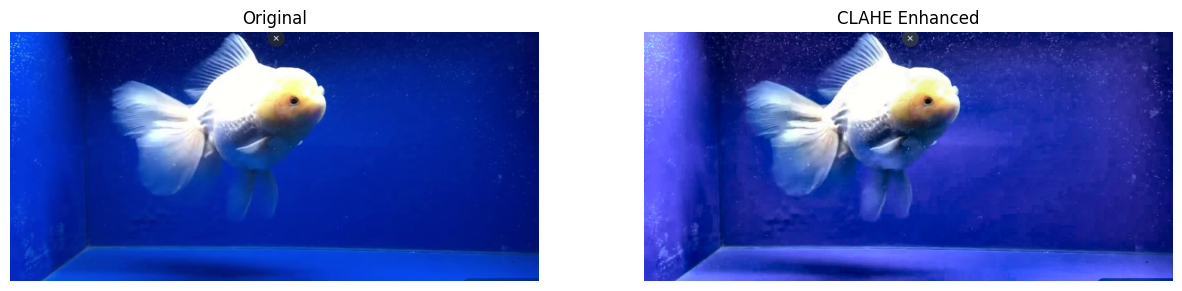

In [14]:
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

raw_folder = Path("/content/drive/MyDrive/FishProject/extracted_frames")
clahe_folder = Path("/content/drive/MyDrive/FishProject/clahe_frames")

raw_images = list(raw_folder.rglob("*.jpg"))

sample = random.choice(raw_images)

relative = sample.relative_to(raw_folder)
enhanced = clahe_folder / relative

raw = cv2.cvtColor(cv2.imread(str(sample)), cv2.COLOR_BGR2RGB)
clahe = cv2.cvtColor(cv2.imread(str(enhanced)), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.imshow(raw)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(clahe)
plt.title("CLAHE Enhanced")
plt.axis("off")

plt.show()

read processing report

In [15]:
report_path = "/content/drive/MyDrive/FishProject/reports/clahe_processing_report.txt"

with open(report_path, "r") as f:
    print(f.read())

AQUACULTURAL ENGINEERING - PREPROCESSING PERFORMANCE REPORT

[Dataset Summary]
Source Directory          : /content/drive/MyDrive/FishProject/extracted_frames
Total Images Discovered   : 623

[Processing Summary]
Success Count             : 623
Failure Count             : 0
Skipped Count             : 0
Average Processing Time   : 0.8090 seconds

[Output Locations]
Enhanced Directory        : /content/drive/MyDrive/FishProject/clahe_frames
Comparisons Directory     : /content/drive/MyDrive/FishProject/comparison_images
Summary Table CSV         : /content/drive/MyDrive/FishProject/metadata/clahe_summary.csv
Statistics Payload JSON   : /content/drive/MyDrive/FishProject/reports/processing_statistics.json

Execution Timestamp       : 2026-06-26 05:35:32



read statistics csv

In [16]:
import pandas as pd

csv_path = "/content/drive/MyDrive/FishProject/metadata/clahe_summary.csv"

df = pd.read_csv(csv_path)

df.head()

,Image Name,Input Path,Output Path,Status,Processing Time (seconds),Brightness Before,Brightness After,Contrast Before,Contrast After,Mean Before,Mean After,Std Before,Std After
0,frame_000000.jpg,/content/drive/MyDrive/FishProject/extracted_f...,/content/drive/MyDrive/FishProject/clahe_frame...,SUCCESS,1.0621,172.3451,150.7944,55.2522,60.0257,172.3451,150.7944,55.2522,60.0257
1,frame_000012.jpg,/content/drive/MyDrive/FishProject/extracted_f...,/content/drive/MyDrive/FishProject/clahe_frame...,SUCCESS,1.1685,176.1673,153.6375,54.4963,59.7373,176.1673,153.6375,54.4963,59.7373
2,frame_000024.jpg,/content/drive/MyDrive/FishProject/extracted_f...,/content/drive/MyDrive/FishProject/clahe_frame...,SUCCESS,0.1021,176.4794,152.8362,53.1796,59.1512,176.4794,152.8362,53.1796,59.1512
3,frame_000036.jpg,/content/drive/MyDrive/FishProject/extracted_f...,/content/drive/MyDrive/FishProject/clahe_frame...,SUCCESS,0.0926,176.1326,152.3567,54.0846,60.0270,176.1326,152.3567,54.0846,60.0270
4,frame_000048.jpg,/content/drive/MyDrive/FishProject/extracted_f...,/content/drive/MyDrive/FishProject/clahe_frame...,SUCCESS,0.1156,173.6620,152.0120,55.7578,60.1936,173.6620,152.0120,55.7578,60.1936


check comparision images

Comparison Images: 20


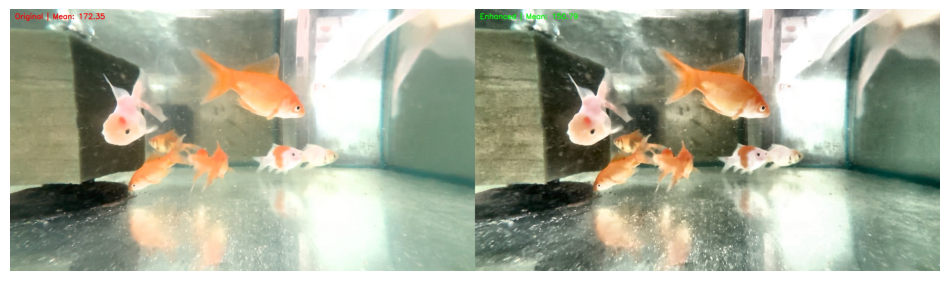

In [17]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

comparison_folder = Path("/content/drive/MyDrive/FishProject/comparison_images")

comparison_images = list(comparison_folder.glob("*"))

print(f"Comparison Images: {len(comparison_images)}")

img = Image.open(comparison_images[0])

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.show()

verifying image size

In [18]:
import cv2
from pathlib import Path

raw_root = Path("/content/drive/MyDrive/FishProject/extracted_frames")
clahe_root = Path("/content/drive/MyDrive/FishProject/clahe_frames")

for raw_file in raw_root.rglob("*.jpg"):
    rel = raw_file.relative_to(raw_root)
    clahe_file = clahe_root / rel

    raw = cv2.imread(str(raw_file))
    enhanced = cv2.imread(str(clahe_file))

    if raw.shape != enhanced.shape:
        print(f"Shape mismatch: {rel}")
        break
else:
    print("✓ All enhanced images preserve original dimensions.")

✓ All enhanced images preserve original dimensions.


In [19]:
import cv2
import numpy as np
from pathlib import Path

raw_root = Path("/content/drive/MyDrive/FishProject/extracted_frames")
clahe_root = Path("/content/drive/MyDrive/FishProject/clahe_frames")

brightness_changes = []
contrast_changes = []

for raw_file in raw_root.rglob("*.jpg"):
    rel = raw_file.relative_to(raw_root)

    raw = cv2.imread(str(raw_file), cv2.IMREAD_GRAYSCALE)
    enhanced = cv2.imread(str(clahe_root / rel), cv2.IMREAD_GRAYSCALE)

    brightness_changes.append(np.mean(enhanced) - np.mean(raw))
    contrast_changes.append(np.std(enhanced) - np.std(raw))

print(f"Average Brightness Change : {np.mean(brightness_changes):.2f}")
print(f"Average Contrast Change   : {np.mean(contrast_changes):.2f}")

Average Brightness Change : -17.17
Average Contrast Change   : 11.00
